### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [22]:
import polars as pl
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import numpy as np
import scipy.stats as stats


In [2]:
df= pl.read_csv(r"C:\Users\Ready2Use\Desktop\my-folder\Ironhack-week5\Day2\lab-eda-bivariate\amz_uk_price_prediction_dataset.csv", try_parse_dates=True)
print(df)

shape: (2_443_651, 9)
┌─────────┬────────────┬─────────────┬───────┬───┬───────┬─────────────┬─────────────┬─────────────┐
│ uid     ┆ asin       ┆ title       ┆ stars ┆ … ┆ price ┆ isBestSelle ┆ boughtInLas ┆ category    │
│ ---     ┆ ---        ┆ ---         ┆ ---   ┆   ┆ ---   ┆ r           ┆ tMonth      ┆ ---         │
│ i64     ┆ str        ┆ str         ┆ f64   ┆   ┆ f64   ┆ ---         ┆ ---         ┆ str         │
│         ┆            ┆             ┆       ┆   ┆       ┆ bool        ┆ i64         ┆             │
╞═════════╪════════════╪═════════════╪═══════╪═══╪═══════╪═════════════╪═════════════╪═════════════╡
│ 1       ┆ B09B96TG33 ┆ Echo Dot    ┆ 4.7   ┆ … ┆ 21.99 ┆ false       ┆ 0           ┆ Hi-Fi       │
│         ┆            ┆ (5th        ┆       ┆   ┆       ┆             ┆             ┆ Speakers    │
│         ┆            ┆ generation, ┆       ┆   ┆       ┆             ┆             ┆             │
│         ┆            ┆ 2022…       ┆       ┆   ┆       ┆           

In [3]:
#1. **Crosstab Analysis**:
# Create a crosstab between the product `category` and the `isBestSeller` status.
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

# Display the crosstab
print(crosstab_result)

col_0                           False  True 
row_0                                       
3D Printers                       247      1
3D Printing & Scanning           4065      2
Abrasive & Finishing Products     245      5
Action Cameras                   1696      1
Adapters                          251      3
...                               ...    ...
Wind Instruments                  243      7
Window Treatments                 234      5
Women                           17559    213
Women's Sports & Outdoor Shoes   1939     20
eBook Readers & Accessories       246      0

[296 rows x 2 columns]


In [4]:
#    Are there categories where being a best-seller is more prevalent? 
# *Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*
if True not in crosstab_result.columns:
    crosstab_result[True] = 0
if False not in crosstab_result.columns:
    crosstab_result[False] = 0

# Calculate the proportion of bestsellers for each category
crosstab_result['Proportion_Bestsellers'] = (crosstab_result[True] 
                                             / (crosstab_result[True] + crosstab_result[False]))

# Sort the categories based on the proportion of bestsellers
sorted_categories = crosstab_result.sort_values(by='Proportion_Bestsellers', ascending=False)

# Show the sorted DataFrame
print(sorted_categories)

col_0                           False  True  Proportion_Bestsellers
row_0                                                              
Grocery                          9008   556                0.058135
Smart Home Security & Lighting     98     6                0.057692
Health & Personal Care           9017   552                0.057686
Mobile Phone Accessories          248    11                0.042471
Power & Hand Tools               8353   306                0.035339
...                               ...   ...                     ...
Bedding Collections              6309     0                0.000000
CPUs                              249     0                0.000000
CD, Disc & Tape Players          8798     0                0.000000
Blank Media Cases & Wallets       243     0                0.000000
eBook Readers & Accessories       246     0                0.000000

[296 rows x 3 columns]


In [5]:
top_5_categories = sorted_categories.head(5)
display(top_5_categories)

col_0,False,True,Proportion_Bestsellers
row_0,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339


The top 5 categories with the most bestsellers are:
1. Grocery
2. Smart Home Security & Lighting
3. Health & Personal care
4. Mobile Phone Accessories
5. Power & Hand Tools

In [6]:
#2. **Statistical Tests**:
    # Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    

# Perform the Chi-Square test
chi2, p, dof, ex = chi2_contingency(crosstab_result)

# Output the results
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 36684.23786636857
p-value: 0.0
Degrees of freedom: 590


In [7]:
# Calculate Cramér's V
n = crosstab_result.values.sum()  # Total number of observations in crosstab_result
min_dim = min(crosstab_result.shape) - 1  # Minimum dimension minus one

cramers_v = np.sqrt(chi2 / (n * min_dim))

# Output computed Cramér's V
print("Cramér's V:", cramers_v)

Cramér's V: 0.08663731815334759


There is a relationship between category and bestseller status as show by Chi2 and p-value. But Cramer V shows that the relationship is weak.

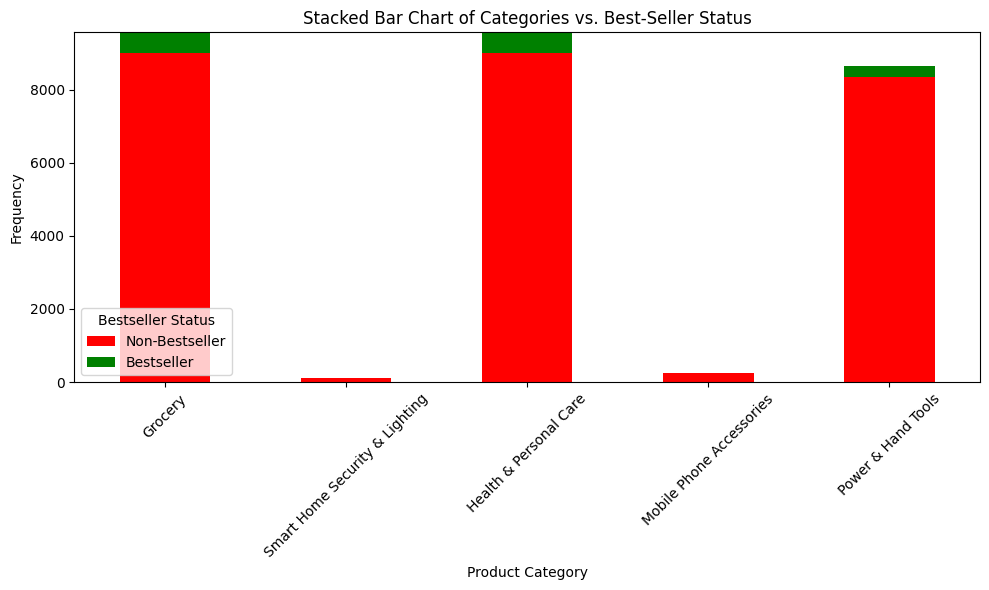

In [8]:
#3. **Visualizations**:
# Visualize the relationship between product categories and the best-seller status using a stacked bar chart.
# Plot a stacked bar chart
ax = top_5_categories.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Set titles and labels
plt.title('Stacked Bar Chart of Categories vs. Best-Seller Status')
plt.xlabel('Product Category')
plt.ylabel('Frequency')
plt.legend(title='Bestseller Status', labels=['Non-Bestseller', 'Bestseller'])
plt.xticks(rotation=45)  # Rotate x-axis labels for readability

# Display the plot
plt.tight_layout()  # Adjust layout for better fitting
plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [9]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers using `filter`
    outliers = data.filter((data < lower_bound) | (data > upper_bound))

    return outliers


data_series = df['price']
outliers = tukeys_test_outliers(data_series)

# To get DataFrame without outliers
non_outliers_df = df.filter((data_series >= data_series.quantile(0.25) - 1.5 * (data_series.quantile(0.75) - data_series.quantile(0.25)))
                            & (data_series <= data_series.quantile(0.75) + 1.5 * (data_series.quantile(0.75) - data_series.quantile(0.25))))

# Print the outliers
print(outliers)

# Print non-outliers DataFrame
display(non_outliers_df)


shape: (327_688,)
Series: 'price' [f64]
[
	139.0
	164.99
	149.99
	289.0
	199.99
	…
	166.99
	152.58
	108.77
	166.99
	158.99
]


uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
i64,str,str,f64,i64,f64,bool,i64,str
1,"""B09B96TG33""","""Echo Dot (5th generation, 2022…",4.7,15308,21.99,false,0,"""Hi-Fi Speakers"""
2,"""B01HTH3C8S""","""Anker Soundcore mini, Super-Po…",4.7,98099,23.99,true,0,"""Hi-Fi Speakers"""
3,"""B09B8YWXDF""","""Echo Dot (5th generation, 2022…",4.7,15308,21.99,false,0,"""Hi-Fi Speakers"""
4,"""B09B8T5VGV""","""Echo Dot with clock (5th gener…",4.7,7205,31.99,false,0,"""Hi-Fi Speakers"""
5,"""B09WX6QD65""","""Introducing Echo Pop | Full so…",4.6,1881,17.99,false,0,"""Hi-Fi Speakers"""
…,…,…,…,…,…,…,…,…
2828589,"""B0CHSD7P2Q""","""Motorbike Armour, Motorbike Cl…",0.0,0,22.34,false,0,"""Motorbike Clothing"""
2828590,"""B0B7B8FNBQ""","""PROFIRST Waterproof Motorcycle…",0.0,0,97.99,false,0,"""Motorbike Clothing"""
2828591,"""B0BD5FL5FB""","""Men’s Motorcycle Motorbike Bik…",0.0,0,52.99,false,0,"""Motorbike Clothing"""


C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_28352\2364327625.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  top_categories_df = non_outliers_df.filter(
C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_28352\2364327625.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top_categories_pd, x='category', y='price', palette='muted')


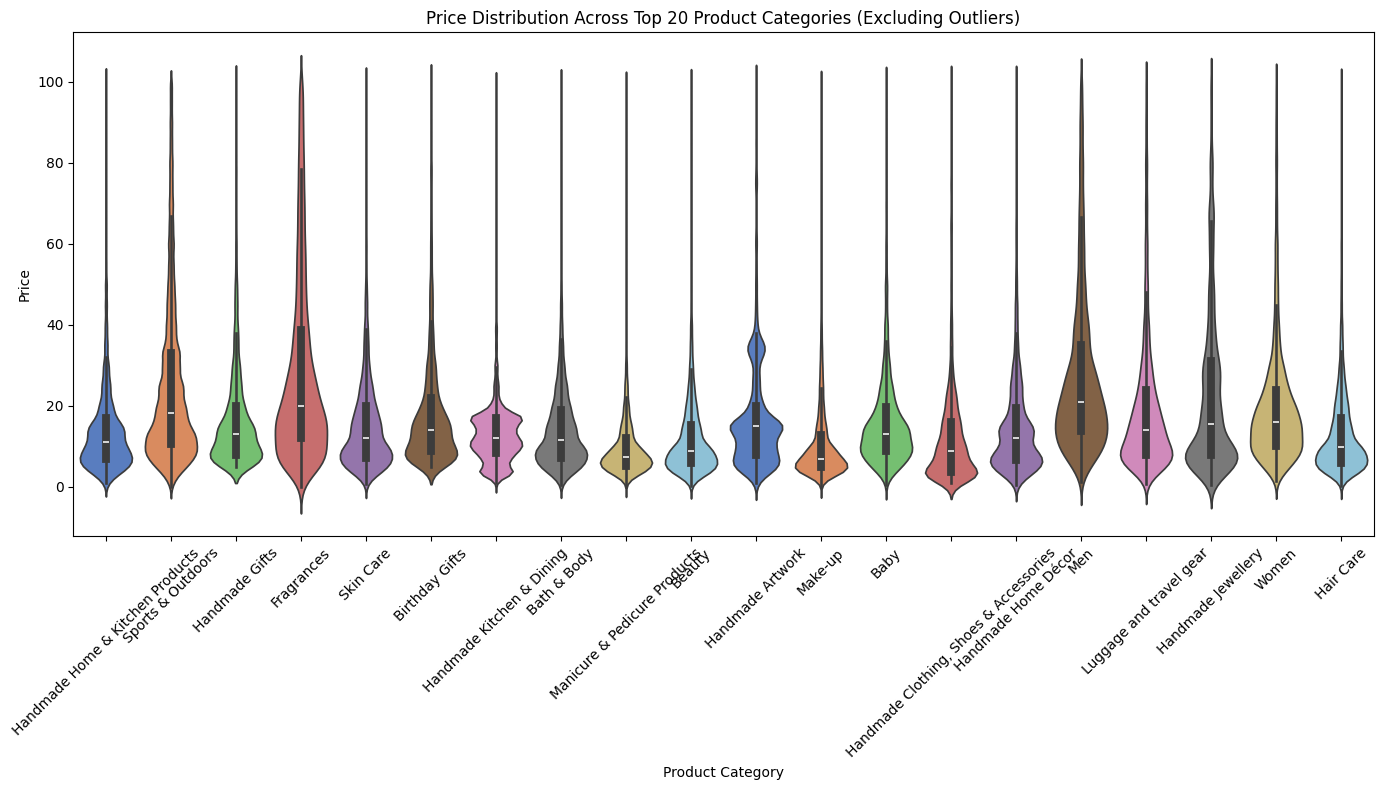

In [10]:
# Calculate number of entries per category using `value_counts`
category_counts = non_outliers_df['category'].value_counts(sort=True)

# Get the top 20 categories based on their count
top_20_categories = category_counts.head(20)

# Filter the original DataFrame to include only rows from these top categories
top_categories_df = non_outliers_df.filter(
    pl.col('category').is_in(top_20_categories['category'])
)

# Convert to pandas DataFrame for plotting with Seaborn
top_categories_pd = top_categories_df.to_pandas()

# Create a violin plot using the pandas DataFrame
plt.figure(figsize=(14, 8))
sns.violinplot(data=top_categories_pd, x='category', y='price', palette='muted')

# Add labels and title
plt.title('Price Distribution Across Top 20 Product Categories (Excluding Outliers)')
plt.xlabel('Product Category')
plt.ylabel('Price')
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

In [15]:
non_outliers_df.columns

['uid',
 'asin',
 'title',
 'stars',
 'reviews',
 'price',
 'isBestSeller',
 'boughtInLastMonth',
 'category']

In [ ]:
#  - Which product category tends to have the highest median price? Don't filter here by top categories.
# Group by 'category' and calculate the median price for each category using Polars
median_price_by_category = non_outliers_df.group_by('category').agg(
    pl.col('price').median().alias('median_price')
)

# Sort by 'median_price' in descending order and get the top entry
highest_median_price = median_price_by_category.sort('median_price', descending=True).head(1)

# Display the result
print("Category with the highest median price:")
print(highest_median_price)

Category with the highest median price:
shape: (1, 2)
┌─────────────┬──────────────┐
│ category    ┆ median_price │
│ ---         ┆ ---          │
│ str         ┆ f64          │
╞═════════════╪══════════════╡
│ Desktop PCs ┆ 74.0         │
└─────────────┴──────────────┘


The product category with the highest median price is Desktop PCs

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

In [ ]:
#1. **Correlation Coefficients**:
    # Calculate the correlation coefficient between `price` and `stars`.
    # Is there a significant correlation between product price and its rating?
# Calculate the correlation coefficient between 'price' and 'stars'
correlation = non_outliers_df.select(
    pl.corr('price', 'stars').alias('correlation')
)

print("Correlation coefficient between price and stars:")
print(correlation)

Correlation coefficient between price and stars:
shape: (1, 1)
┌─────────────┐
│ correlation │
│ ---         │
│ f64         │
╞═════════════╡
│ -0.077673   │
└─────────────┘


# Is there a significant correlation between product price and its rating?
There is a moderate negative correlation between stars and prices.

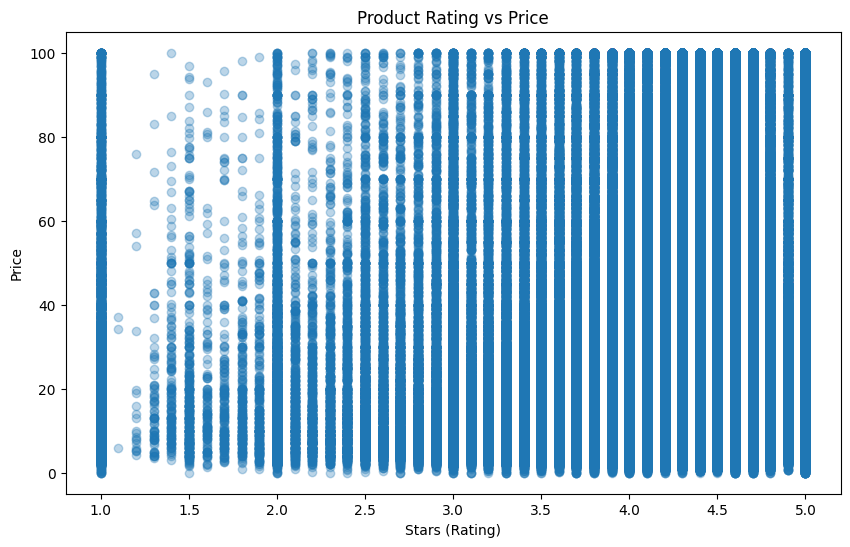

In [26]:
# Filter out 0-star products
filtered_df = non_outliers_df.filter(pl.col('stars') > 0)

plt.figure(figsize=(10, 6))
plt.scatter(
    np.array(filtered_df['stars'].to_list()),
    filtered_df['price'].to_list(),
    alpha=0.3
)
plt.xlabel('Stars (Rating)')
plt.ylabel('Price')
plt.title('Product Rating vs Price')
plt.show()

Patterns:
- customers rate more for lower priced products
- from 3 stars up, the price matters less for the rating
- a lot of products are not rated
- a surprising number of products are rated with only 1 star
  

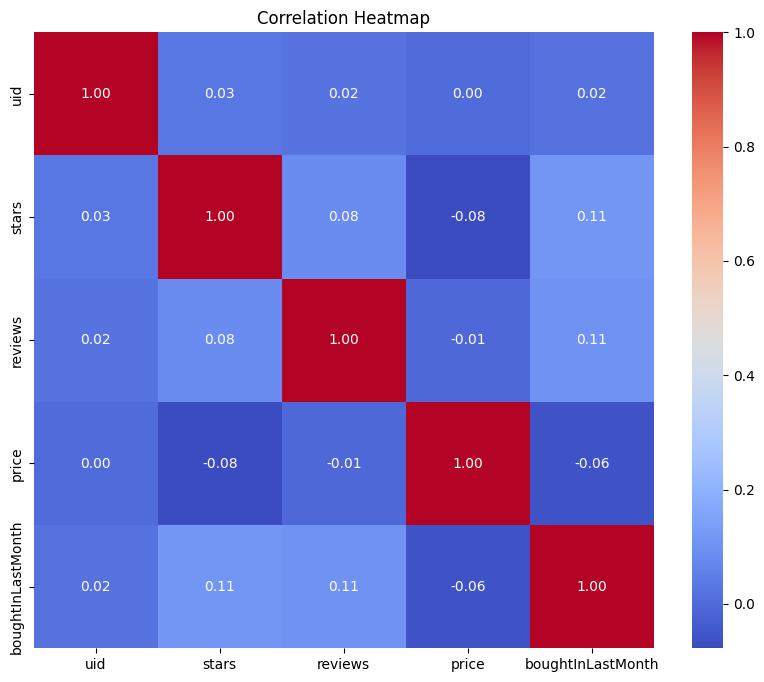

In [20]:
#Use a correlation heatmap to visualize correlations between all numerical variables.
# Get only numerical columns and convert to pandas (seaborn needs pandas)
numerical_df = non_outliers_df.select(pl.col(pl.Float64, pl.Int64)).to_pandas()

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

The correlation between the numerical collumns are very weak to non existant

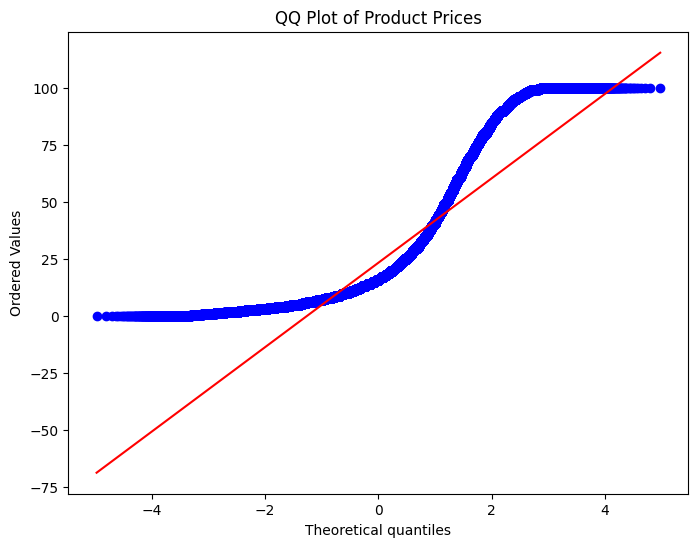

In [23]:
#Examine if product prices typically follow a normal distribution using a QQ plot. 
plt.figure(figsize=(8, 6))
stats.probplot(non_outliers_df['price'].to_list(), dist="norm", plot=plt)
plt.title('QQ Plot of Product Prices')
plt.show()

- The dots strongly deviate from the red line on both ends — this means that product prices are not normally distributed.
- Left end (flat cluster near 0): There are a lot of products priced at or near €0, way more than a normal distribution would predict. This creates that flat horizontal line on the left.
- Right end (flat cluster near 100): Similarly, many products are capped at €100 (remember, I removed outliers!), creating another flat line on the right.
The S-shape of the dots is a classic sign of a distribution that is "light-tailed" compared to normal — meaning the data is squeezed between 0 and 100 rather than spreading out freely.

Overall conclusion: Product prices are not normally distributed, which honestly makes total sense for e-commerce data — prices tend to cluster at certain popular price points (€0.99, €9.99, €49.99, €99.99) rather than being smoothly spread out like a bell curve.